In [83]:
# 导入常用库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fp = r"D:\AI\task2\FZU\FZU_data.csv"
df = pd.read_csv(fp, encoding='utf-8', low_memory=False,header=0)

df_original = df.copy()
print('数据行列：', df.shape)
df.head(10)

数据行列： (598, 31)


,通知人,标题,日期,详情链接,下载量1,附件1,附件链接1,下载量2,附件2,附件链接2,...,附件链接6,下载量7,附件7,附件链接7,下载量8,附件8,附件链接8,下载量9,附件9,附件链接9
0,教学运行,关于组织2025级新生开展学籍信息自查工作的通知,2025-10-11,https://jwch.fzu.edu.cn/info/1036/14245.htm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,质量办,关于举办福州大学第七十三场“教学有道”研讨活动的通知,2025-09-28,https://jwch.fzu.edu.cn/info/1040/14235.htm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,教学运行,关于2025-2026-01学期体育理论教室安排（2025级）的通知,2025-09-26,https://jwch.fzu.edu.cn/info/1036/14232.htm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,教学运行,关于2025年国庆节、中秋节放假课程调整的通知,2025-09-24,https://jwch.fzu.edu.cn/info/1036/14229.htm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,综合科,关于召开2025-2026学年秋季学期期初本科教育教学工作会议的通知,2025-09-23,https://jwch.fzu.edu.cn/info/1035/14228.htm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,实践科,关于举办2025年福州大学大学生工程实践与创新能力大赛的通知,2025-09-23,https://jwch.fzu.edu.cn/content.jsp?urltype=ne...,108.0,附件1：2025年福州大学大学生工程实践与创新能力大赛组委会成员名单.docx,https://jwch.fzu.edu.cn/system/_content/downlo...,141.0,附件2：2025年福州大学大学生工程实践与创新能力大赛报名表.docx,https://jwch.fzu.edu.cn/system/_content/downlo...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,教学运行,关于做好2025-2026学年第二学期排课准备工作的通知,2025-09-22,https://jwch.fzu.edu.cn/info/1036/14225.htm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,教学运行,关于2025-2026学年第一学期重新学习选课、缴费的通知,2025-09-22,https://jwch.fzu.edu.cn/info/1036/14224.htm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,计划科,关于2025-2026学年第一学期参加《大学生国家安全教育》课程学习的通知,2025-09-22,https://jwch.fzu.edu.cn/info/1038/14223.htm,2838.0,超星尔雅使用手册（学生版）.pdf,https://jwch.fzu.edu.cn/system/_content/downlo...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,计划科,关于通识教育选修课《国际化拔尖创新人才科研训练2025秋》宣讲会及选课的通知,2025-09-19,https://jwch.fzu.edu.cn/info/1038/14220.htm,1184.0,2025年秋季国际化拔尖创新人才科研训练具体课程清单.xlsx,https://jwch.fzu.edu.cn/system/_content/downlo...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. 「通知人」都有谁？ 统计所有出现过的「通知人」，并计算他们各自发布的通知数量占总数的比例。

In [84]:

counts_map = {}
for item in df["通知人"]:
    counts_map[item] = counts_map.get(item, 0) + 1
count = df["通知人"].value_counts()
total = count.sum()
p = (count / total).rename('比例')
sender_stats = pd.concat([count.rename('发布数量'), p], axis=1)
sender_stats.head(50)

,发布数量,比例
通知人,,
教学运行,191,0.319398
实践科,150,0.250836
质量办,71,0.118729
计划科,61,0.102007
教研教改,48,0.080268
综合科,45,0.075251
教材中心,26,0.043478
教学通知,5,0.008361
电教中心,1,0.001672


## 2. 附件下载次数与通知人关系

In [ ]:

# 查找所有下载量列并计算每行总和（skipna=True 默认开启，会自动跳过 NaN）
download_cols = [c for c in df.columns if '下载量' in c]
df['_下载次数_'] = df[download_cols].sum(axis=1)

# 筛选出下载量列不全为 NaN 的行,subset 参数指定要检查缺失值（NaN）的列子集。
download = (
    df[['通知人'] + download_cols]
    .dropna(subset=download_cols, how='all')
)
count = download.shape[0]
# 1. 按通知人分组时，可以同时计算多个统计指标
download_stats = download.groupby('通知人').agg(['sum', 'mean', 'count'])

# 2. 填充NaN为0，使结果更清晰
download_stats = download.groupby('通知人').sum().fillna(0)
# 4. 计算每个通知人的下载总量（所有列的和）
download_stats['总计'] = download_stats.sum(axis=1)
download_stats['平均'] = download_stats['总计'] / count
download_stats = download_stats[['总计', '平均']]
download_stats = download_stats.rename(columns=lambda x: x + '_总下载量')
download_stats.head(50)

Note: you may need to restart the kernel to use updated packages.


,总计_总下载量,平均_总下载量
通知人,,
实践科,261822.0,861.256579
教学运行,135564.0,445.934211
教学通知,2815.0,9.259868
教材中心,25287.0,83.180921
教研教改,80685.0,265.411184
综合科,4660.0,15.328947
计划科,63049.0,207.398026
质量办,41947.0,137.983553


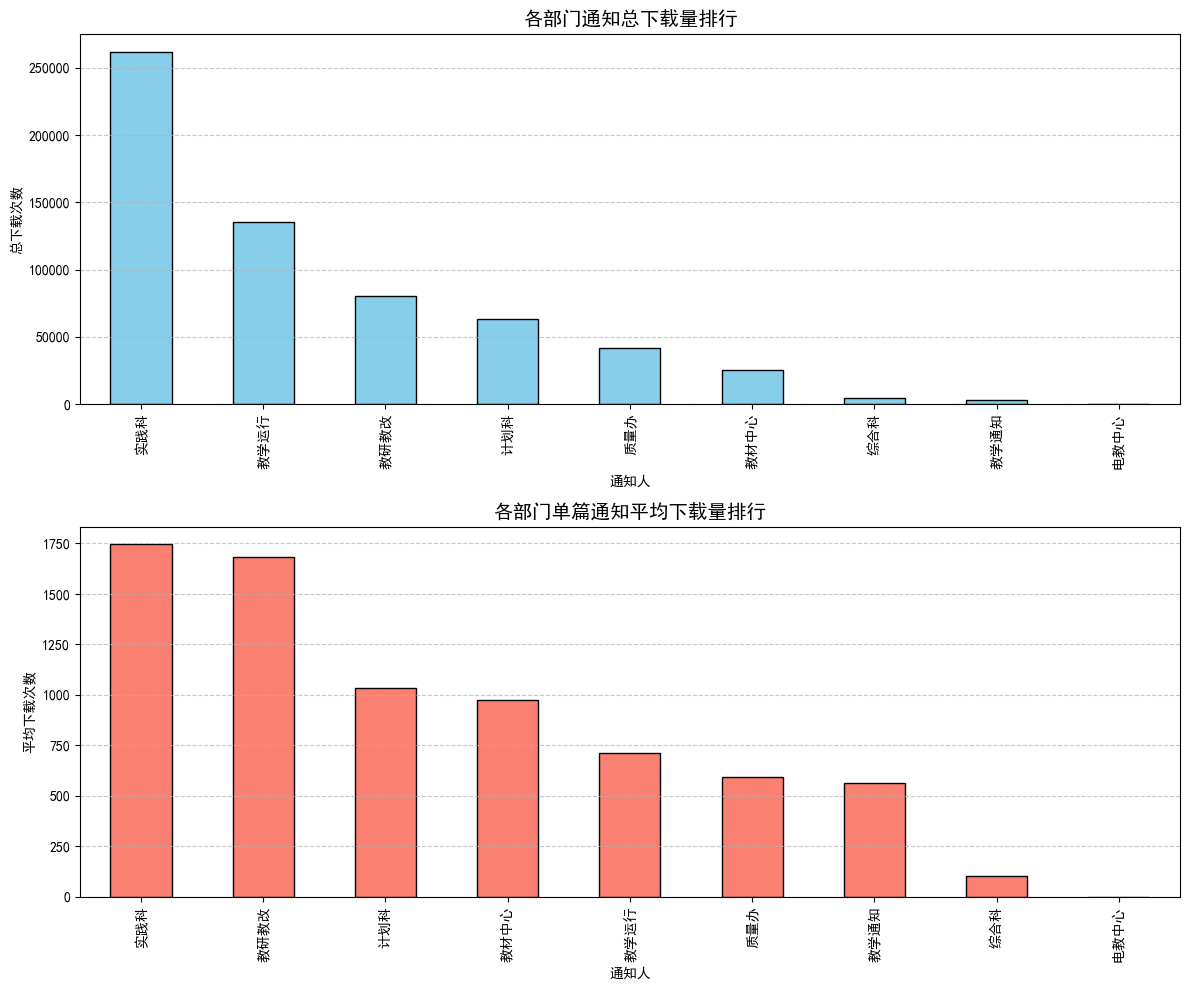

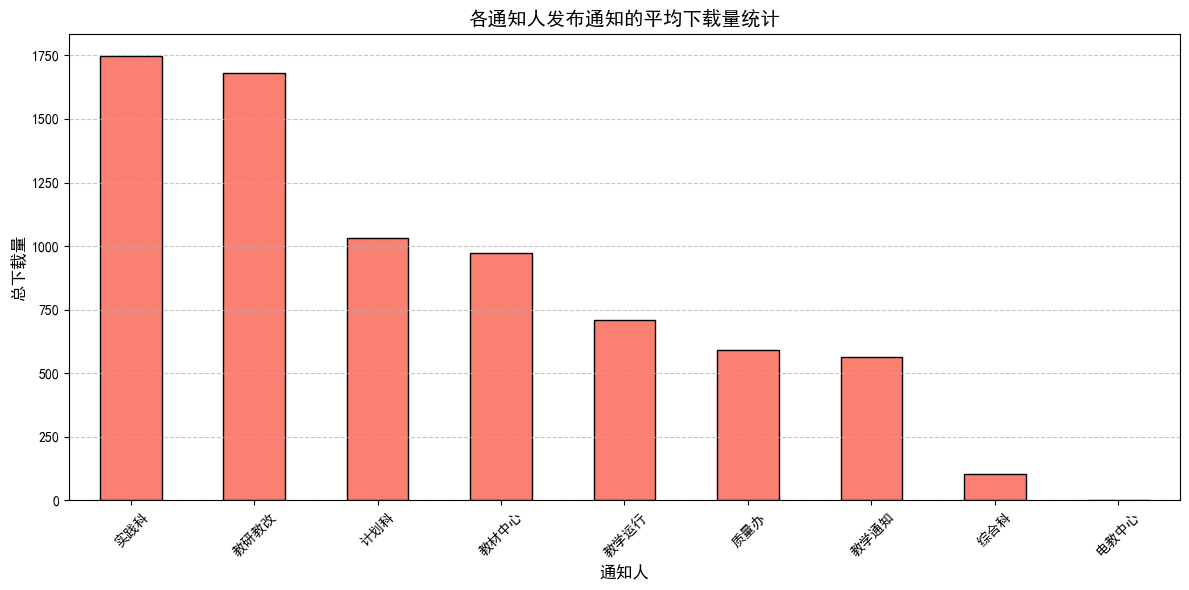

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
# 设置中文字体以确保正常显示渲染
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False


# 直接使用已有的 `_下载次数_` 列进行汇总，计算各通知人的总下载量与平均下载量
#使用 ax 参数（在同一图形中）
download_stats = df.groupby('通知人')['_下载次数_'].agg(['sum', 'mean'])
download_stats.columns = ['总计_总下载量', '平均_总下载量']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

#  统计总下载量 (反映部门的整体影响力/附件总量)
download_stats['总计_总下载量'].sort_values(ascending=False).plot(
    kind='bar', ax=ax1, color='skyblue', edgecolor='black'
)
ax1.set_title('各部门通知总下载量排行', fontsize=14)
ax1.set_ylabel('总下载次数')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 统计平均下载量 (反映单个通知的吸引力/重要程度)
download_stats['平均_总下载量'].sort_values(ascending=False).plot(
    kind='bar', ax=ax2, color='salmon', edgecolor='black'
)
ax2.set_title('各部门单篇通知平均下载量排行', fontsize=14)
ax2.set_ylabel('平均下载次数')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 绘制各通知人发布数量的柱状图
plt.figure(figsize=(12, 6))
download_stats['平均_总下载量'].sort_values(ascending=False).plot(kind='bar', color='salmon', edgecolor='black')
plt.title('各通知人发布通知的平均下载量统计', fontsize=14)
plt.xlabel('通知人', fontsize=12)
plt.ylabel('总下载量', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. 通知发布时间分析：寻找高峰期

In [87]:

time_cols = [c for c in df.columns if ( c =='日期')]

df['_发布时间_raw_'] = df[time_cols]
df['_发布时间_raw_'] = pd.to_datetime(df[time_cols[0]])

# 统计每天发布的通知数量
daily_counts = df.groupby('_发布时间_raw_').size().rename('发布数量')
daily_counts.sort_values(ascending=False).head(50)

# 获取发布数量最多的20天
top_20_days_df = daily_counts.sort_values(ascending=False).head(20).reset_index()
# 按月份统计发布数量
df['月份'] = df['_发布时间_raw_'].dt.to_period('M')
monthly_counts_df = df.groupby('月份').size().reset_index(name='月发布数量')

# 展示结果
print("发布数量最多的20天：")
print(top_20_days_df)
print("\n每月发布统计：")
print(monthly_counts_df)

发布数量最多的20天：
   _发布时间_raw_  发布数量
0  2024-01-02     6
1  2023-08-26     6
2  2025-02-22     6
3  2025-04-22     5
4  2025-05-12     5
5  2024-08-30     5
6  2024-02-25     5
7  2024-12-25     5
8  2024-06-05     5
9  2023-06-20     5
10 2025-09-12     5
11 2025-09-10     5
12 2025-09-06     5
13 2025-06-24     4
14 2024-12-24     4
15 2024-04-26     4
16 2024-08-25     4
17 2024-09-02     4
18 2023-05-26     4
19 2023-09-14     4

每月发布统计：
         月份  月发布数量
0   2022-12      6
1   2023-01      5
2   2023-02     14
3   2023-03     20
4   2023-04     17
5   2023-05     30
6   2023-06     24
7   2023-07      3
8   2023-08     21
9   2023-09     18
10  2023-10     13
11  2023-11     17
12  2023-12     22
13  2024-01     15
14  2024-02     10
15  2024-03     17
16  2024-04     28
17  2024-05     20
18  2024-06     26
19  2024-07      6
20  2024-08     12
21  2024-09     32
22  2024-10     12
23  2024-11     19
24  2024-12     31
25  2025-01     10
26  2025-02     10
27  2025-03     15
28  2025

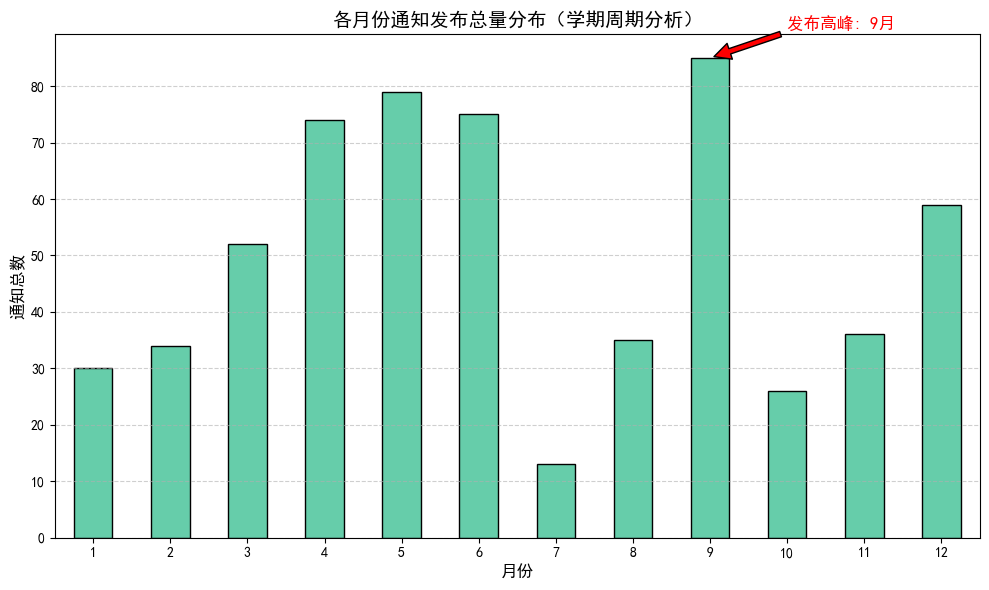

各月发布趋势（降序）：
月份_num
9     85
5     79
6     75
4     74
12    59
3     52
11    36
8     35
2     34
1     30
10    26
7     13
dtype: int64


In [88]:
import matplotlib.pyplot as plt
import pandas as pd
# 提取月份（1-12）进行跨年统计
df['月份_num'] = df['_发布时间_raw_'].dt.month

# 统计每个自然月的通知总数（反映学期周期性）
monthly_seasonality = df.groupby('月份_num').size()

# 绘图可视化
plt.figure(figsize=(10, 6))
monthly_seasonality.plot(kind='bar', color='mediumaquamarine', edgecolor='black')

plt.title('各月份通知发布总量分布（学期周期分析）', fontsize=14)
plt.xlabel('月份', fontsize=12)
plt.ylabel('通知总数', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 自动标注最高峰
max_month = monthly_seasonality.idxmax()
max_val = monthly_seasonality.max()
plt.annotate(f'发布高峰: {max_month}月', xy=(max_month-1, max_val), 
             xytext=(max_month, max_val + 5),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='red')

plt.tight_layout()
plt.show()

# 输出简要结论
print("各月发布趋势（降序）：")
print(monthly_seasonality.sort_values(ascending=False))

## 通知的标题长度和阅读量 / 下载量有关吗？

标题长度与下载量的 Pearson 相关系数为: -0.0227


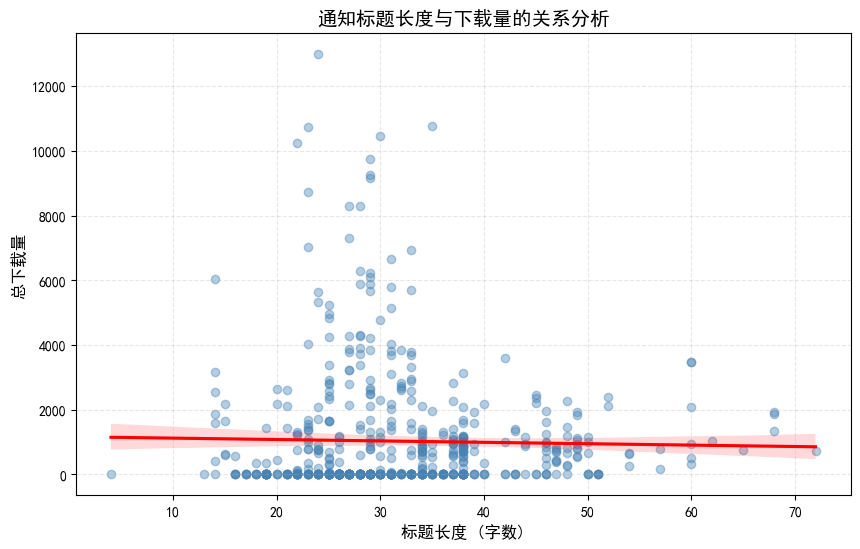


不同标题长度区间的平均下载量：
长度分组
0-10        0.000000
11-20     584.428571
21-30    1246.322097
31-40     906.776650
41-50     824.721311
50+      1107.869565
Name: _下载次数_, dtype: float64


C:\Users\star\AppData\Local\Temp\ipykernel_50992\727770191.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('长度分组')['_下载次数_'].mean()


In [89]:

import matplotlib.pyplot as plt
import pandas as pd
# 1. 计算标题长度
df['标题长度'] = df['标题'].str.len()

# 2. 计算 Pearson 相关系数
correlation = df['标题长度'].corr(df['_下载次数_'])
print(f"标题长度与下载量的 Pearson 相关系数为: {correlation:.4f}")

# 3. 绘制散点图与回归线
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='标题长度', y='_下载次数_', 
            scatter_kws={'alpha':0.4, 'color':'steelblue'}, 
            line_kws={'color':'red'})

plt.title('通知标题长度与下载量的关系分析', fontsize=14)
plt.xlabel('标题长度 (字数)', fontsize=12)
plt.ylabel('总下载量', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. 按标题长度区间查看平均下载量趋势
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '50+']
df['长度分组'] = pd.cut(df['标题长度'], bins=bins, labels=labels)

group_stats = df.groupby('长度分组')['_下载次数_'].mean()
print("\n不同标题长度区间的平均下载量：")
print(group_stats)